In [74]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from sklearn.cluster import KMeans
from sklearn import preprocessing
import matplotlib.pyplot as pl
import seaborn as sns

#source: https://stackoverflow.com/questions/33458834/k-means-clustering-in-python
#source: https://stackoverflow.com/questions/57986346/how-to-do-clustering-with-k-means-algorithm-for-an-imported-data-set-with-proper
#genAI used in debugging and where directly cited

In [75]:
project_location = Path.cwd()
print(project_location)

/Users/oliviawesel/Desktop/soccer-analytics-capstone-template/analysis/kmeans


In [76]:
# path = project_location/ 'all_k_means.csv'
df = pd.read_csv(project_location/'all_k_means.csv')
print(df.head())

   player_id  pct_shot_first_time  pct_shot_follows_dribble  \
0      20527             0.166667                  0.000000   
1       5198             0.350000                  0.000000   
2       6732             0.322314                  0.000000   
3      24035             0.390071                  0.000000   
4       5503             0.219304                  0.001774   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.166667                0.166667         0.833333   
1            0.040000                0.550000         0.200000   
2            0.016529                0.859504         0.016529   
3            0.035461                0.716312         0.120567   
4            0.010646                0.842796         0.045067   

   pct_shot_goal_scored  pct_shot_taken_saved  shots_per_minute  \
0              0.166667              0.000000          0.011173   
1              0.170000              0.000000          0.033000   
2              0.181818

Drop nulls

In [77]:
df.isnull().sum()
print(len(df))

9035


In [78]:
df.dropna(inplace=True)
print(len(df))

4746


In [79]:
df = df.drop(columns=['player_id'])

Normalize with MinMax scaling

In [80]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.166667,0.000000,0.166667,0.166667,0.833333,0.166667,0.000000,0.005511,0.053062,1.000000,...,0.033429,0.000000,0.600000,0.056285,0.000000,0.152595,0.148218,0.288642,0.549719,0.002450
1,0.350000,0.000000,0.040000,0.550000,0.200000,0.170000,0.000000,0.027586,0.061922,0.480000,...,0.040293,0.291667,0.800000,0.025929,0.062230,0.368770,0.208297,0.320457,0.306828,0.016908
2,0.322314,0.000000,0.016529,0.859504,0.016529,0.181818,0.008264,0.032726,0.072260,0.214876,...,0.041448,0.444444,0.222222,0.042755,0.149644,0.273423,0.184481,0.330105,0.395883,0.032202
3,0.390071,0.000000,0.035461,0.716312,0.120567,0.134752,0.028369,0.039890,0.048515,0.226950,...,0.029508,0.339286,0.857143,0.043254,0.173018,0.285616,0.185376,0.294700,0.408857,0.014852
4,0.219304,0.001774,0.010646,0.842796,0.045067,0.191980,0.008517,0.058108,1.000000,0.208304,...,0.089312,0.299180,0.461668,0.207415,0.063954,0.261681,0.226403,0.317442,0.370999,0.034574


Select cluster size

In [81]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

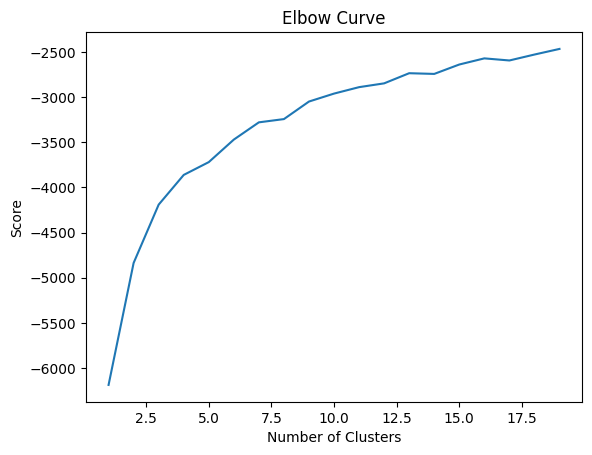

In [82]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [83]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster
0,0.166667,0.000000,0.166667,0.166667,0.833333,0.166667,0.000000,0.011173,-0.062036,1.000000,...,0.000000,0.600000,0.009381,0.000000,0.114447,0.148218,0.187617,0.549719,0.001725,0
1,0.350000,0.000000,0.040000,0.550000,0.200000,0.170000,0.000000,0.033000,1.407565,0.480000,...,0.291667,0.800000,0.004322,0.020743,0.276577,0.208297,0.208297,0.306828,0.011907,0
2,0.322314,0.000000,0.016529,0.859504,0.016529,0.181818,0.008264,0.038081,3.122359,0.214876,...,0.444444,0.222222,0.007126,0.049881,0.205067,0.184481,0.214568,0.395883,0.022678,2
3,0.390071,0.000000,0.035461,0.716312,0.120567,0.134752,0.028369,0.045165,-0.816248,0.226950,...,0.339286,0.857143,0.007209,0.057673,0.214212,0.185376,0.191555,0.408857,0.010459,2
4,0.219304,0.001774,0.010646,0.842796,0.045067,0.191980,0.008517,0.063178,157.005264,0.208304,...,0.299180,0.461668,0.034569,0.021318,0.196261,0.226403,0.206337,0.370999,0.024348,2


In [84]:
len(df.columns)

45

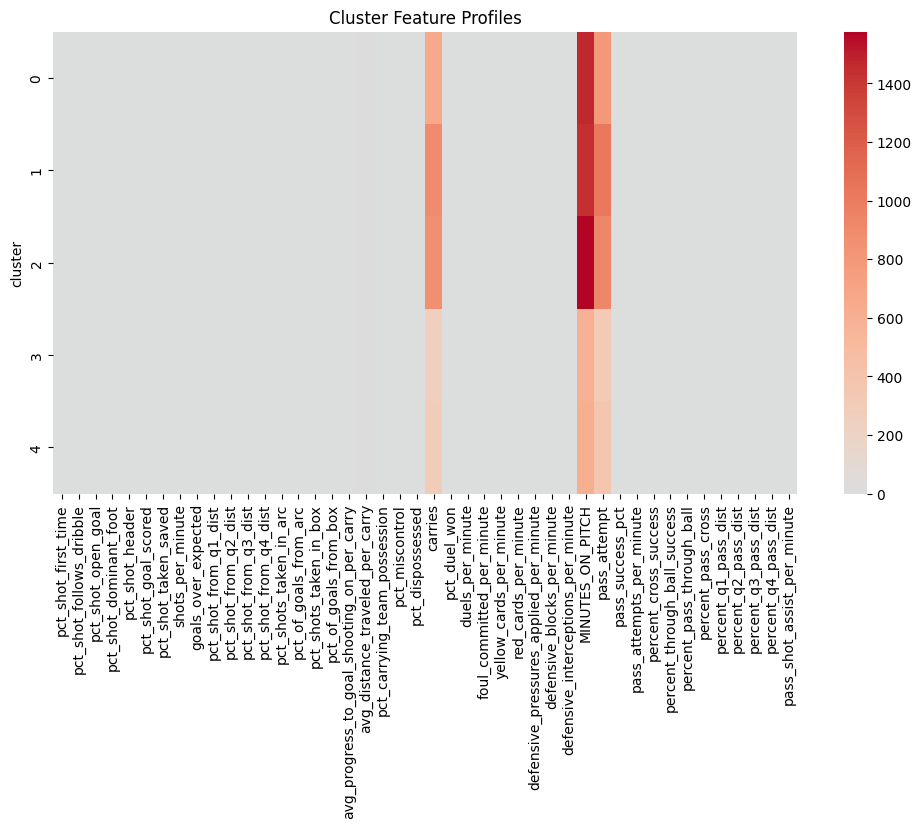

In [85]:
#used genAI
cluster_means = df.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()